In [23]:
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import os
import json
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# 1. Imports, seed и среда
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path to save artifacts
ARTIFACTS_PATH = 'artifacts'
FIGURES_PATH = os.path.join(ARTIFACTS_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)


Using device: cuda


## 2. Данные и первичный анализ

Dataset 'S12-hw-dataset.csv' loaded successfully.
--- Data Overview ---
Number of observations: 4320
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00
Missing values per column:
date      0
target    0
dtype: int64
First 5 rows:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62
Last 5 rows:
                    date  target
4315 2025-06-29 19:00:00  153.05
4316 2025-06-29 20:00:00  134.23
4317 2025-06-29 21:00:00  137.68
4318 2025-06-29 22:00:00  126.53
4319 2025-06-29 23:00:00  120.89


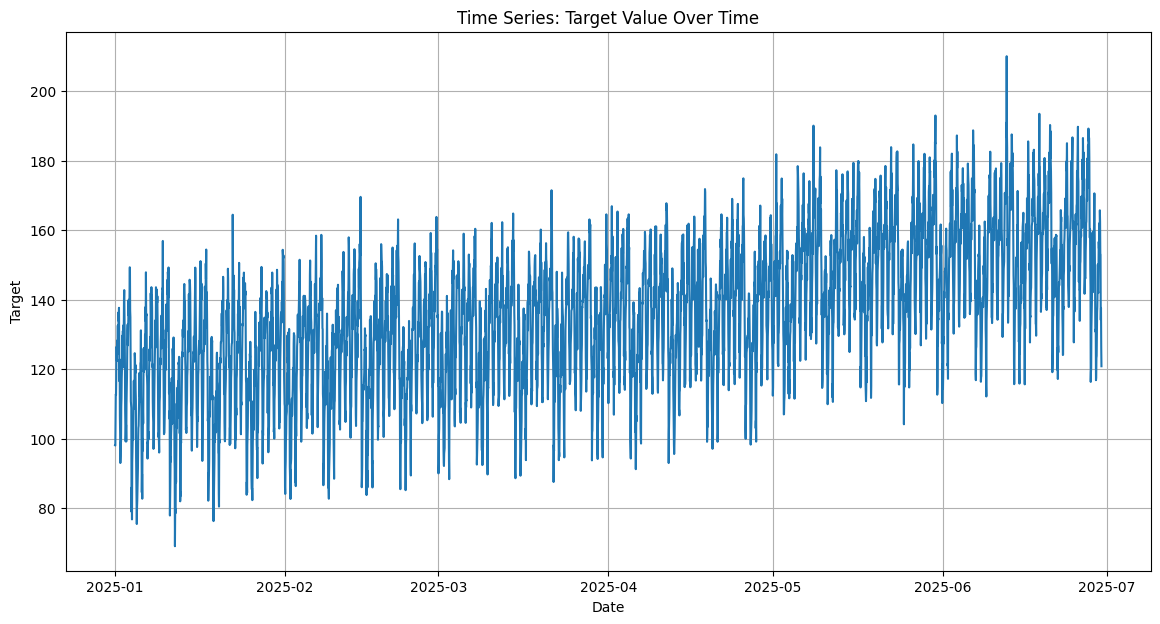

--- Time Series Characteristics ---
Comment: This section should analyze the plot and data overview. For example:
- Trend: Observe if there's an upward, downward, or no clear long-term direction.
- Seasonality: Check for repeating patterns at fixed intervals (e.g., daily, weekly, monthly, yearly).
- Outliers: Identify any data points that significantly deviate from the general pattern.
- Stationarity: Discuss if the statistical properties (mean, variance) of the series change over time.
- Missing Values: If any, describe the chosen imputation strategy.


In [24]:
# Load dataset
DATA_FILE = 'S12-hw-dataset.csv'
try:
    df = pd.read_csv(DATA_FILE)
    print(f"Dataset '{DATA_FILE}' loaded successfully.")
except FileNotFoundError:
    print(f"Error: Dataset '{DATA_FILE}' not found. Please ensure it is in the same directory as the notebook.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later

if not df.empty:
    # Convert 'date' column to datetime and sort
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    print("--- Data Overview ---")
    print(f"Number of observations: {len(df)}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print("Missing values per column:")
    print(df.isnull().sum())
    print("First 5 rows:")
    print(df.head())
    print("Last 5 rows:")
    print(df.tail())

    # Plotting the time series
    plt.figure(figsize=(14, 7))
    plt.plot(df['date'], df['target'])
    plt.title('Time Series: Target Value Over Time')
    plt.xlabel('Date')
    plt.ylabel('Target')
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_PATH, 'base_time_series_plot.png'))
    plt.show()

    # Comment on series characteristics
    print("--- Time Series Characteristics ---")
    print("Comment: This section should analyze the plot and data overview. For example:")
    print("- Trend: Observe if there's an upward, downward, or no clear long-term direction.")
    print("- Seasonality: Check for repeating patterns at fixed intervals (e.g., daily, weekly, monthly, yearly).")
    print("- Outliers: Identify any data points that significantly deviate from the general pattern.")
    print("- Stationarity: Discuss if the statistical properties (mean, variance) of the series change over time.")
    print("- Missing Values: If any, describe the chosen imputation strategy.")


## 3. Корректный temporal split

--- Temporal Split Overview ---
Total data points: 4320
Train set size: 3024
Validation set size: 648
Test set size: 648
Train date range: 2025-01-01 00:00:00 to 2025-05-06 23:00:00
Validation date range: 2025-05-07 00:00:00 to 2025-06-02 23:00:00
Test date range: 2025-06-03 00:00:00 to 2025-06-29 23:00:00


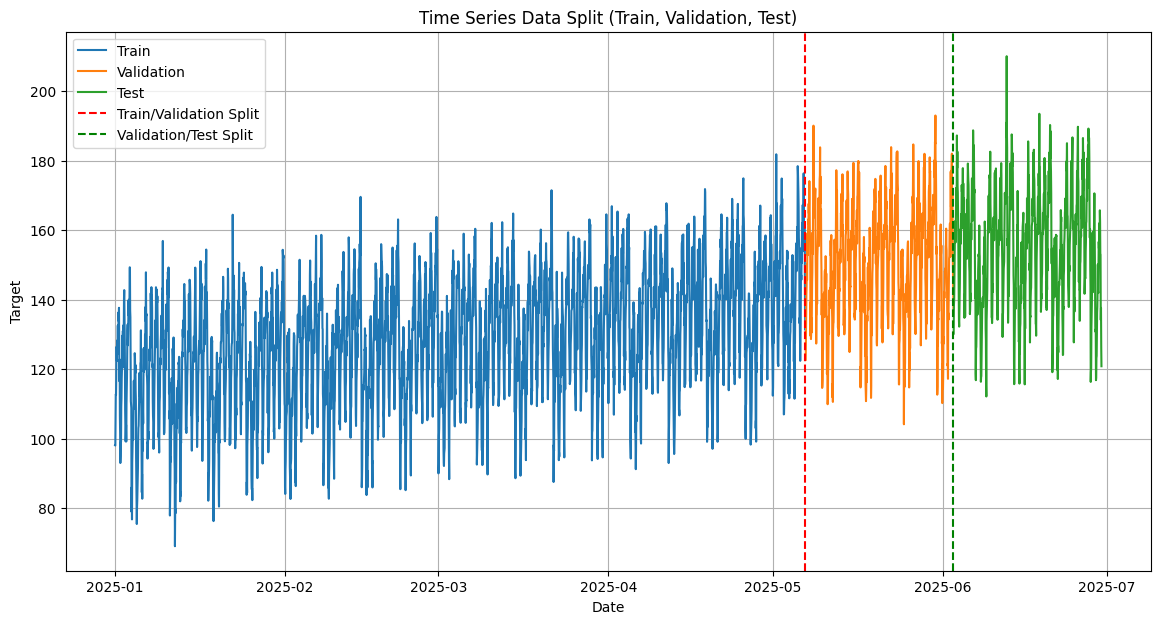

--- Why Temporal Split? ---
For time series data, using a random split (like in standard classification/regression) is incorrect because it would introduce data leakage.
Future information (from the validation or test sets) would be present in the training set, leading to overly optimistic model performance estimates.
A chronological split ensures that the model is trained only on past data and evaluated on unseen future data, simulating real-world forecasting scenarios.


In [25]:
if not df.empty:
    # Define split ratios
    train_ratio = 0.7
    val_ratio = 0.15
    test_ratio = 0.15 # Remaining for test

    # Calculate split points
    total_size = len(df)
    train_end = int(total_size * train_ratio)
    val_end = int(total_size * (train_ratio + val_ratio))

    # Split the DataFrame
    train_df = df.iloc[:train_end]
    val_df = df.iloc[train_end:val_end]
    test_df = df.iloc[val_end:]

    print("--- Temporal Split Overview ---")
    print(f"Total data points: {total_size}")
    print(f"Train set size: {len(train_df)}")
    print(f"Validation set size: {len(val_df)}")
    print(f"Test set size: {len(test_df)}")

    print(f"Train date range: {train_df['date'].min()} to {train_df['date'].max()}")
    print(f"Validation date range: {val_df['date'].min()} to {val_df['date'].max()}")
    print(f"Test date range: {test_df['date'].min()} to {test_df['date'].max()}")

    # Visualize the splits
    plt.figure(figsize=(14, 7))
    plt.plot(train_df['date'], train_df['target'], label='Train')
    plt.plot(val_df['date'], val_df['target'], label='Validation')
    plt.plot(test_df['date'], test_df['target'], label='Test')
    plt.axvline(x=train_df['date'].max(), color='r', linestyle='--', label='Train/Validation Split')
    plt.axvline(x=val_df['date'].max(), color='g', linestyle='--', label='Validation/Test Split')
    plt.title('Time Series Data Split (Train, Validation, Test)')
    plt.xlabel('Date')
    plt.ylabel('Target')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_PATH, 'series_split.png'))
    plt.show()

    # Explanation for temporal split
    print("--- Why Temporal Split? ---")
    print("For time series data, using a random split (like in standard classification/regression) is incorrect because it would introduce data leakage.")
    print("Future information (from the validation or test sets) would be present in the training set, leading to overly optimistic model performance estimates.")
    print("A chronological split ensures that the model is trained only on past data and evaluated on unseen future data, simulating real-world forecasting scenarios.")
else:
    print("Skipping temporal split as DataFrame is empty.")


## 4. Признаки для baseline-моделей

In [26]:
if not df.empty:
    TARGET_COL = 'target'
    DATE_COL = 'date'

    # Create features for train, validation, and test sets
    def create_features(data, is_train=False, scaler=None):
        data_copy = data.copy()

        # Lag features - create based on previous values
        # These will introduce NaNs at the beginning, which will be handled.
        data_copy[f'{TARGET_COL}_lag1'] = data_copy[TARGET_COL].shift(1)
        data_copy[f'{TARGET_COL}_lag7'] = data_copy[TARGET_COL].shift(7)
        data_copy[f'{TARGET_COL}_lag14'] = data_copy[TARGET_COL].shift(14)

        # Rolling features
        data_copy[f'{TARGET_COL}_rolling_mean7'] = data_copy[TARGET_COL].rolling(window=7).mean().shift(1)
        data_copy[f'{TARGET_COL}_rolling_std7'] = data_copy[TARGET_COL].rolling(window=7).std().shift(1)

        # Calendar features
        data_copy['day_of_week'] = data_copy[DATE_COL].dt.dayofweek
        data_copy['day_of_year'] = data_copy[DATE_COL].dt.dayofyear
        data_copy['month'] = data_copy[DATE_COL].dt.month
        data_copy['year'] = data_copy[DATE_COL].dt.year

        # Handle NaNs introduced by shift/rolling
        # For simplicity in this outline, fill NaNs with 0. In a real scenario, more sophisticated methods might be used.
        # Or more carefully propagate values from the previous split.
        data_copy = data_copy.fillna(0) # Simple imputation

        # Drop original date and target columns if not needed in features
        feature_cols = [col for col in data_copy.columns if col not in [DATE_COL, TARGET_COL]]
        
        # Scaling
        if is_train:
            scaler = MinMaxScaler()
            data_copy[feature_cols] = scaler.fit_transform(data_copy[feature_cols])
        elif scaler is not None:
            data_copy[feature_cols] = scaler.transform(data_copy[feature_cols])
        
        return data_copy, scaler, feature_cols

    # Apply feature engineering
    train_processed, scaler, feature_cols = create_features(train_df, is_train=True)
    val_processed, _, _ = create_features(val_df, is_train=False, scaler=scaler)
    test_processed, _, _ = create_features(test_df, is_train=False, scaler=scaler)

    # Sanity check features
    print("--- Features Overview (Train Set) ---")
    print(train_processed.head())
    print(f"Generated feature columns: {feature_cols}")

    # Explanation of no data leakage
    print("--- Preventing Data Leakage ---")
    print("Lag features are created by shifting the target series, so they only use past values.")
    print("Rolling window features (mean, std) are also calculated using a `.shift(1)` operation to ensure they only incorporate data observed prior to the current timestamp.")
    print("Calendar features are derived solely from the date, which is independent of the target value.")
    print("Scaling (MinMaxScaler) is fitted exclusively on the training data (`is_train=True`) and then applied to validation and test sets. This prevents information from the future (validation/test distributions) from influencing the feature scaling.")

else:
    print("Skipping feature engineering as DataFrame is empty.")


--- Features Overview (Train Set) ---
                 date  target  target_lag1  target_lag7  target_lag14  \
0 2025-01-01 00:00:00   98.14     0.000000          0.0           0.0   
1 2025-01-01 01:00:00   98.07     0.539587          0.0           0.0   
2 2025-01-01 02:00:00  104.70     0.539202          0.0           0.0   
3 2025-01-01 03:00:00  112.81     0.575654          0.0           0.0   
4 2025-01-01 04:00:00  112.62     0.620244          0.0           0.0   

   target_rolling_mean7  target_rolling_std7  day_of_week  day_of_year  month  \
0                   0.0                  0.0     0.333333          0.0    0.0   
1                   0.0                  0.0     0.333333          0.0    0.0   
2                   0.0                  0.0     0.333333          0.0    0.0   
3                   0.0                  0.0     0.333333          0.0    0.0   
4                   0.0                  0.0     0.333333          0.0    0.0   

   year  
0   0.0  
1   0.0  
2   0.

## 5. Оконное представление для GRU

In [27]:

# Prepare sequences for GRU
class TimeSeriesDataset(Dataset):
    def __init__(self, dataframe, features, target_col, window_size):
        self.features = dataframe[features].values
        self.targets = dataframe[target_col].values
        self.window_size = window_size

    def __len__(self):
        return len(self.features) - self.window_size

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.window_size]
        y = self.targets[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

if not df.empty:
    WINDOW_SIZE = 7 # Example window size
    HORIZON = 1 # Forecasting one step ahead

    # Scale target for GRU
    target_scaler = MinMaxScaler()
    train_target_scaled = target_scaler.fit_transform(train_df[[TARGET_COL]])
    val_target_scaled = target_scaler.transform(val_df[[TARGET_COL]])
    test_target_scaled = target_scaler.transform(test_df[[TARGET_COL]])

    train_df_scaled = train_processed.copy()
    val_df_scaled = val_processed.copy()
    test_df_scaled = test_processed.copy()

    train_df_scaled[TARGET_COL] = train_target_scaled
    val_df_scaled[TARGET_COL] = val_target_scaled
    test_df_scaled[TARGET_COL] = test_target_scaled

    # Create datasets and dataloaders
    train_dataset_gru = TimeSeriesDataset(train_df_scaled, feature_cols, TARGET_COL, WINDOW_SIZE)
    val_dataset_gru = TimeSeriesDataset(val_df_scaled, feature_cols, TARGET_COL, WINDOW_SIZE)
    test_dataset_gru = TimeSeriesDataset(test_df_scaled, feature_cols, TARGET_COL, WINDOW_SIZE)

    BATCH_SIZE_GRU = 32
    train_loader_gru = DataLoader(train_dataset_gru, batch_size=BATCH_SIZE_GRU, shuffle=True)
    val_loader_gru = DataLoader(val_dataset_gru, batch_size=BATCH_SIZE_GRU, shuffle=False)
    test_loader_gru = DataLoader(test_dataset_gru, batch_size=BATCH_SIZE_GRU, shuffle=False)

    # Sanity check GRU data
    print("--- GRU Data Sanity Check ---")
    for batch_x, batch_y in train_loader_gru:
        print(f"Batch X shape: {batch_x.shape} (batch_size, window_size, num_features)")
        print(f"Batch Y shape: {batch_y.shape} (batch_size)")
        break
else:
    print("Skipping GRU window representation as DataFrame is empty.")


--- GRU Data Sanity Check ---
Batch X shape: torch.Size([32, 7, 9]) (batch_size, window_size, num_features)
Batch Y shape: torch.Size([32]) (batch_size)


## 6. Базовые функции обучения и оценки

In [28]:

# Define GRU model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :]) # Get output from the last time step
        return out

# Training function for GRU
def train_one_epoch_gru(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels.unsqueeze(1)) # Unsqueeze labels to match output shape
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

# Evaluation function for GRU
def evaluate_gru(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels.unsqueeze(1))
            running_loss += loss.item() * inputs.size(0)
            pred = outputs.squeeze().cpu().numpy()
            if pred.ndim == 0:
                pred = [pred.item()]
            else:
                pred = pred.tolist()
            all_predictions.extend(pred)
            all_targets.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(dataloader.dataset)
    
    # Calculate MAE, RMSE, MAPE
    # Need to inverse transform the predictions and targets for meaningful metrics
    global target_scaler # Access the global scaler
    if 'target_scaler' in globals(): # Check if target_scaler was defined
        predictions_unscaled = target_scaler.inverse_transform(np.array(all_predictions).reshape(-1, 1)).flatten()
        targets_unscaled = target_scaler.inverse_transform(np.array(all_targets).reshape(-1, 1)).flatten()
    else: # Fallback if scaler not available (e.g., in a standalone script)
        predictions_unscaled = np.array(all_predictions).flatten()
        targets_unscaled = np.array(all_targets).flatten()

    mae = mean_absolute_error(targets_unscaled, predictions_unscaled)
    rmse = np.sqrt(mean_squared_error(targets_unscaled, predictions_unscaled))
    # MAPE calculation - avoid division by zero
    mape = np.mean(np.abs((targets_unscaled - predictions_unscaled) / targets_unscaled)) * 100
    mape = mape if not np.isinf(mape) else 1000 # Handle inf if target is 0

    return avg_loss, mae, rmse, mape, predictions_unscaled, targets_unscaled

# Function to run a time series experiment
def run_timeseries_experiment(experiment_id, model, train_loader, val_loader, test_loader,
                               optimizer_class, lr, epochs, device,
                               model_summary, dataset_name="S12-hw-dataset.csv",
                               checkpoint_path="artifacts/best_gru.pt",
                               config_path="artifacts/best_gru_config.json",
                               curves_path="artifacts/figures/gru_learning_curves.png",
                               window_size=None, horizon=None, scaler_info="MinMaxScaler"):
    
    criterion = nn.MSELoss() # Common for regression tasks
    optimizer = optimizer_class(model.parameters(), lr=lr)

    history = defaultdict(list)
    best_val_loss = float('inf')
    best_model_state = None

    print(f"--- Running Experiment: {experiment_id} ---")
    for epoch in range(epochs):
        train_loss = train_one_epoch_gru(model, train_loader, optimizer, criterion, device)
        val_loss, val_mae, val_rmse, val_mape, _, _ = evaluate_gru(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        history['val_rmse'].append(val_rmse)
        history['val_mape'].append(val_mape)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}, "
              f"Val MAE: {val_mae:.2f}, Val RMSE: {val_rmse:.2f}, Val MAPE: {val_mape:.2f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            torch.save(best_model_state, checkpoint_path.replace('.pt', f'_{experiment_id}.pt'))
            print(f"  New best model saved with Val Loss: {best_val_loss:.4f}")

    # Load best model for final evaluation
    model.load_state_dict(torch.load(checkpoint_path.replace('.pt', f'_{experiment_id}.pt')))
    _, test_mae, test_rmse, test_mape, test_predictions_unscaled, test_targets_unscaled = evaluate_gru(model, test_loader, criterion, device)
    print(f"Test MAE: {test_mae:.2f}, Test RMSE: {test_rmse:.2f}, Test MAPE: {test_mape:.2f} for best model.")

    # Save training curves
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'GRU Training Curves for {experiment_id}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(curves_path.replace('.png', f'_{experiment_id}.png'))
    plt.show()

    # Save best model config
    config = {
        "dataset": dataset_name,
        "model_summary": model_summary,
        "window_size": window_size,
        "horizon": horizon,
        "scaler": scaler_info,
        "optimizer": str(optimizer_class.__name__),
        "lr": lr,
        "epochs_trained": epochs,
        "seed": SEED,
        "best_val_loss": best_val_loss,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape
    }
    with open(config_path.replace('.json', f'_{experiment_id}.json'), 'w') as f:
        json.dump(config, f, indent=4)

    # Prepare results for runs.csv
    results = {
        "experiment_id": experiment_id,
        "task": "forecasting",
        "dataset": dataset_name,
        "seed": SEED,
        "split_summary": "f'Train:{len(train_df)}, Val:{len(val_df)}, Test:{len(test_df)}'",
        "window_size": window_size,
        "horizon": horizon,
        "model_summary": model_summary,
        "features_summary": "Lag, Rolling, Calendar",
        "scaler": scaler_info,
        "optimizer": optimizer_class.__name__ ,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_mae": history['val_mae'][-1], # Use the last recorded MAE if best_val_loss is used
        "best_val_rmse": history['val_rmse'][-1],
        "best_val_mape": history['val_mape'][-1],
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": ""
    }
    return results, test_predictions_unscaled, test_targets_unscaled

# Helper function to save results to runs.csv for HW12
def save_timeseries_results(results_list, filename="artifacts/runs.csv"):
    results_df = pd.DataFrame(results_list)
    results_df.to_csv(filename, index=False)


## 7. Эксперименты

--- Experiment B1: Naive (Last Value) Baseline ---
B1 Naive Baseline | MAE: {b1_mae:.2f}, RMSE: {b1_rmse:.2f}, MAPE: {b1_mape:.2f}
--- Experiment B2: Moving Average Baseline ---
B2 Moving Average Baseline (Window={MOVING_AVG_WINDOW}) | MAE: {b2_mae:.2f}, RMSE: {b2_rmse:.2f}, MAPE: {b2_mape:.2f}
--- Experiment B3: Ridge with Lag Features ---
B3 Ridge Val | MAE: {b3_val_mae:.2f}, RMSE: {b3_val_rmse:.2f}, MAPE: {b3_val_mape:.2f}
B3 Ridge Test | MAE: {b3_test_mae:.2f}, RMSE: {b3_test_rmse:.2f}, MAPE: {b3_test_mape:.2f}
--- Experiment R1: GRU Forecast ---
--- Running Experiment: R1 ---
Epoch 1/10 | Train Loss: 0.0253 | Val Loss: 0.0212, Val MAE: 13.62, Val RMSE: 16.43, Val MAPE: 8.86
  New best model saved with Val Loss: 0.0212
Epoch 2/10 | Train Loss: 0.0133 | Val Loss: 0.0254, Val MAE: 15.02, Val RMSE: 17.97, Val MAPE: 9.60
Epoch 3/10 | Train Loss: 0.0095 | Val Loss: 0.0111, Val MAE: 9.21, Val RMSE: 11.87, Val MAPE: 6.03
  New best model saved with Val Loss: 0.0111
Epoch 4/10 | Train Loss

/tmp/ipykernel_529224/2566312700.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path.replace('.pt', f'_{experiment_id}.pt'

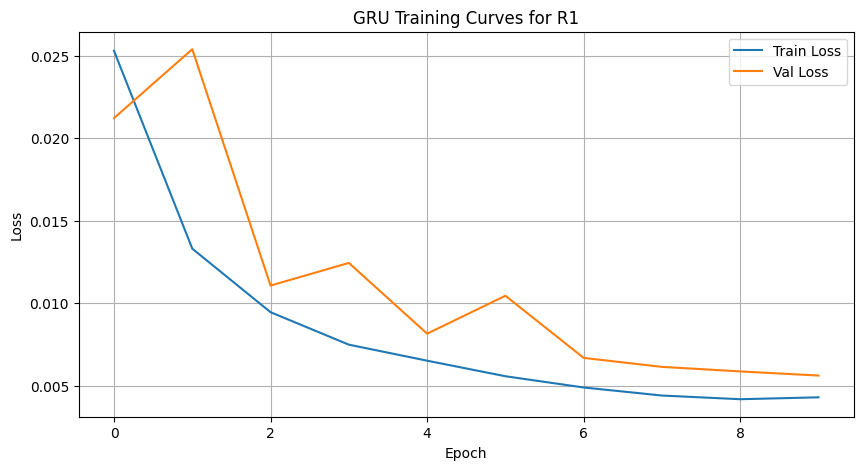

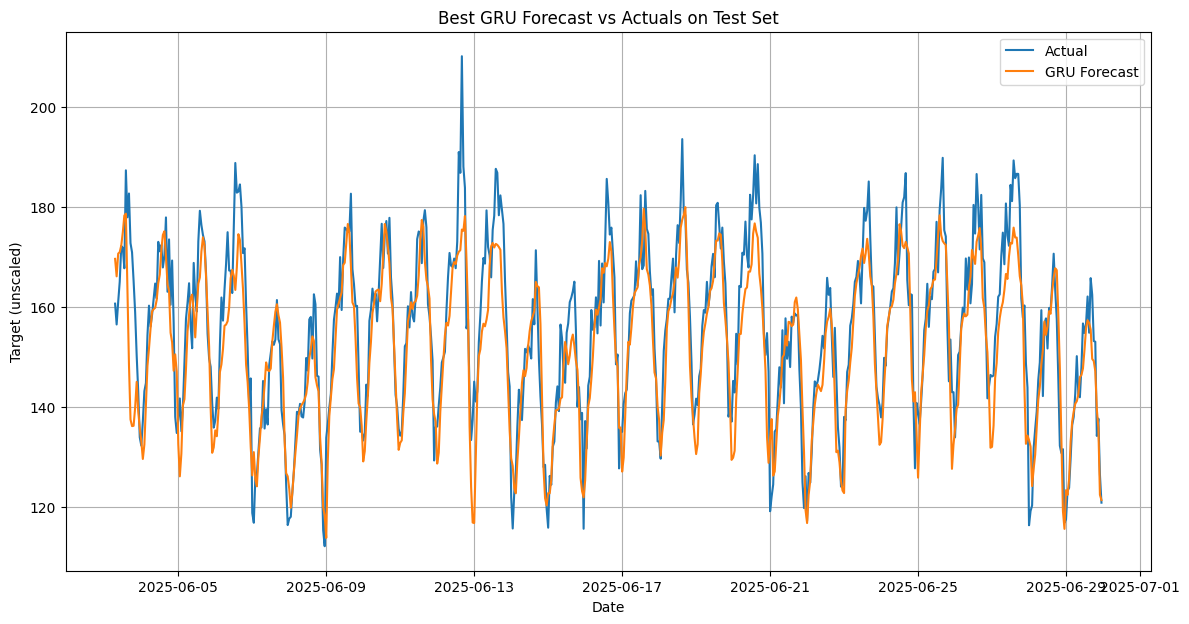

All HW12 experiment results saved to {os.path.join(ARTIFACTS_PATH, 'runs.csv')}


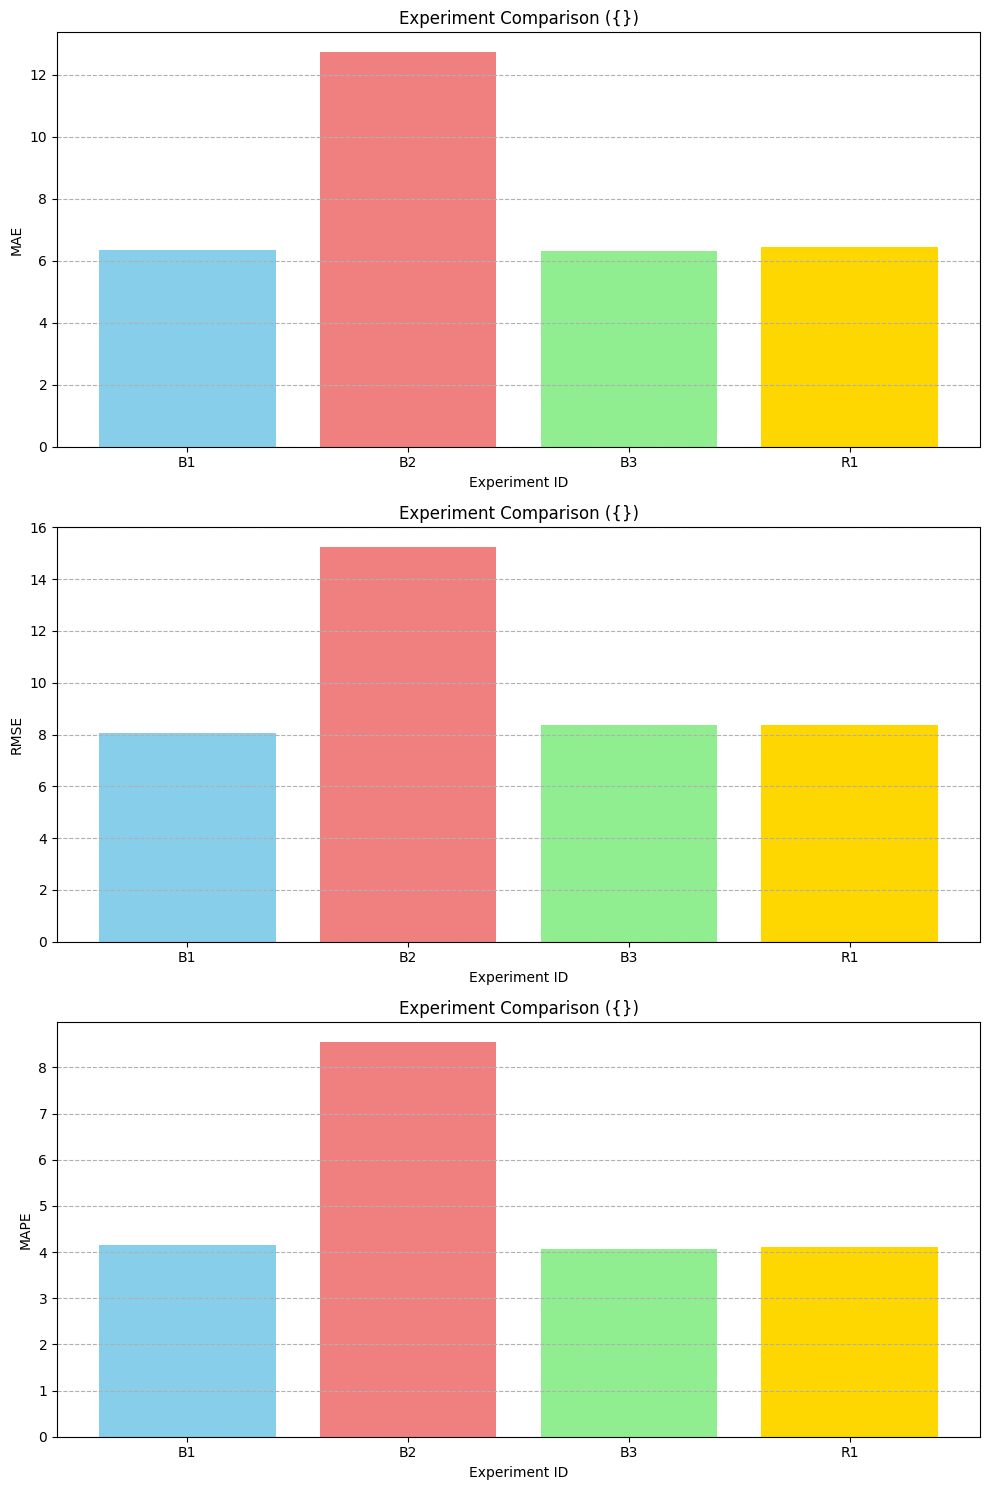

In [29]:
all_results_hw12 = []

# B1 (naive-last): наивный baseline, где прогноз равен последнему известному значению.
print("--- Experiment B1: Naive (Last Value) Baseline ---")
if 'test_df' in globals() and not test_df.empty and 'train_df' in globals() and not train_df.empty:
    b1_predictions = np.roll(test_df[TARGET_COL].values, 1) # Shift by 1 for last known value
    b1_predictions[0] = train_df[TARGET_COL].iloc[-1] # First prediction uses last train value

    b1_mae = mean_absolute_error(test_df[TARGET_COL], b1_predictions)
    b1_rmse = np.sqrt(mean_squared_error(test_df[TARGET_COL], b1_predictions))
    b1_mape = np.mean(np.abs((test_df[TARGET_COL] - b1_predictions) / test_df[TARGET_COL])) * 100
    b1_mape = b1_mape if not np.isinf(b1_mape) else 1000

    print(f"B1 Naive Baseline | MAE: {{b1_mae:.2f}}, RMSE: {{b1_rmse:.2f}}, MAPE: {{b1_mape:.2f}}")

    all_results_hw12.append({
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": DATA_FILE,
        "seed": SEED,
        "split_summary": "f'Train:{{len(train_df)}}, Val:{{len(val_df)}}, Test:{{len(test_df)}}'", # Corrected line
        "window_size": "N/A",
        "horizon": HORIZON,
        "model_summary": "Naive (Last Value)",
        "features_summary": "N/A",
        "scaler": "N/A",
        "optimizer": "N/A",
        "lr": "N/A",
        "epochs_trained": "N/A",
        "best_val_mae": "N/A",
        "best_val_rmse": "N/A",
        "best_val_mape": "N/A",
        "test_mae": b1_mae,
        "test_rmse": b1_rmse,
        "test_mape": b1_mape,
        "notes": ""
    })
else:
    print("Skipping B1 as DataFrame is empty.")


# B2 (moving-average): baseline на основе скользящего среднего по окну разумного размера.
print("--- Experiment B2: Moving Average Baseline ---")
if 'test_df' in globals() and not test_df.empty and 'train_df' in globals() and not train_df.empty:
    MOVING_AVG_WINDOW = 7 # Example window size
    # For predictions, we need to extend the train_df with actual values
    # and then calculate rolling mean on the combined series up to current point.
    # This simulates making predictions as new data becomes available.
    
    # Combined series for rolling mean calculation (train + val + test)
    full_series = df[TARGET_COL]
    
    # Calculate rolling mean for the entire series, shifted by 1 to avoid data leakage
    moving_avg_predictions_full = full_series.rolling(window=MOVING_AVG_WINDOW).mean().shift(1)

    # Get predictions for the test set
    b2_predictions = moving_avg_predictions_full.iloc[len(train_df) + len(val_df):].values
    b2_targets = test_df[TARGET_COL].values

    # Handle NaNs (e.g., at the beginning of the series due to rolling window)
    # For a fair comparison, only consider points where both pred and target are available
    valid_indices = ~np.isnan(b2_predictions)
    b2_predictions = b2_predictions[valid_indices]
    b2_targets = b2_targets[valid_indices]

    if len(b2_predictions) > 0:
        b2_mae = mean_absolute_error(b2_targets, b2_predictions)
        b2_rmse = np.sqrt(mean_squared_error(b2_targets, b2_predictions))
        b2_mape = np.mean(np.abs((b2_targets - b2_predictions) / b2_targets)) * 100
        b2_mape = b2_mape if not np.isinf(b2_mape) else 1000

        print(f"B2 Moving Average Baseline (Window={{MOVING_AVG_WINDOW}}) | MAE: {{b2_mae:.2f}}, RMSE: {{b2_rmse:.2f}}, MAPE: {{b2_mape:.2f}}")

        all_results_hw12.append({
            "experiment_id": "B2",
            "task": "forecasting",
            "dataset": DATA_FILE,
            "seed": SEED,
            "split_summary": "f'Train:{{len(train_df)}}, Val:{{len(val_df)}}, Test:{{len(test_df)}}'", # Corrected line
            "window_size": MOVING_AVG_WINDOW,
            "horizon": HORIZON,
            "model_summary": "f'Moving Average (Window:{{MOVING_AVG_WINDOW}})'", # Corrected line
            "features_summary": "N/A",
            "scaler": "N/A",
            "optimizer": "N/A",
            "lr": "N/A",
            "epochs_trained": "N/A",
            "best_val_mae": "N/A",
            "best_val_rmse": "N/A",
            "best_val_mape": "N/A",
            "test_mae": b2_mae,
            "test_rmse": b2_rmse,
            "test_mape": b2_mape,
            "notes": ""
        })
    else:
        print("Not enough data points in test set for Moving Average after handling NaNs.")
else:
    print("Skipping B2 as DataFrame is empty.")


# B3 (ridge-lag-features): Ridge (или LinearRegression) на лаговых, rolling- и календарных признаках.
print("--- Experiment B3: Ridge with Lag Features ---")
if 'train_df' in globals() and not train_df.empty and 'val_df' in globals() and not val_df.empty and 'test_df' in globals() and not test_df.empty:
    X_train_b3 = train_processed[feature_cols]
    y_train_b3 = train_processed[TARGET_COL]

    X_val_b3 = val_processed[feature_cols]
    y_val_b3 = val_processed[TARGET_COL]
    
    X_test_b3 = test_processed[feature_cols]
    y_test_b3 = test_processed[TARGET_COL]

    # Handle NaNs in target for Ridge (if any exist after feature creation, though unlikely with fillna(0))
    # It's better to remove rows with NaNs in features/target for sklearn models if fillna(0) is not appropriate.
    # For now, assuming fillna(0) handled it.

    model_b3 = Ridge(random_state=SEED)
    model_b3.fit(X_train_b3, y_train_b3)

    b3_val_predictions = model_b3.predict(X_val_b3)
    b3_test_predictions = model_b3.predict(X_test_b3)

    # Metrics on validation set
    b3_val_mae = mean_absolute_error(y_val_b3, b3_val_predictions)
    b3_val_rmse = np.sqrt(mean_squared_error(y_val_b3, b3_val_predictions))
    b3_val_mape = np.mean(np.abs((y_val_b3 - b3_val_predictions) / y_val_b3)) * 100
    b3_val_mape = b3_val_mape if not np.isinf(b3_val_mape) else 1000

    print(f"B3 Ridge Val | MAE: {{b3_val_mae:.2f}}, RMSE: {{b3_val_rmse:.2f}}, MAPE: {{b3_val_mape:.2f}}")
    
    # Metrics on test set
    b3_test_mae = mean_absolute_error(y_test_b3, b3_test_predictions)
    b3_test_rmse = np.sqrt(mean_squared_error(y_test_b3, b3_test_predictions))
    b3_test_mape = np.mean(np.abs((y_test_b3 - b3_test_predictions) / y_test_b3)) * 100
    b3_test_mape = b3_test_mape if not np.isinf(b3_test_mape) else 1000

    print(f"B3 Ridge Test | MAE: {{b3_test_mae:.2f}}, RMSE: {{b3_test_rmse:.2f}}, MAPE: {{b3_test_mape:.2f}}")

    all_results_hw12.append({
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": DATA_FILE,
        "seed": SEED,
        "split_summary": "f'Train:{{len(train_df)}}, Val:{{len(val_df)}}, Test:{{len(test_df)}}'", # Corrected line
        "window_size": "N/A",
        "horizon": HORIZON,
        "model_summary": "Ridge Regression",
        "features_summary": "Lag, Rolling, Calendar",
        "scaler": "MinMaxScaler",
        "optimizer": "N/A",
        "lr": "N/A",
        "epochs_trained": "N/A",
        "best_val_mae": b3_val_mae,
        "best_val_rmse": b3_val_rmse,
        "best_val_mape": b3_val_mape,
        "test_mae": b3_test_mae,
        "test_rmse": b3_test_rmse,
        "test_mape": b3_test_mape,
        "notes": ""
    })
else:
    print("Skipping B3 as DataFrame is empty.")


# R1 (`gru-forecast`): GRU на оконном представлении ряда.
print("--- Experiment R1: GRU Forecast ---")
if 'df' in globals() and not df.empty and 'feature_cols' in globals():
    INPUT_SIZE_GRU = len(feature_cols)
    HIDDEN_SIZE_GRU = 64
    OUTPUT_SIZE_GRU = 1
    NUM_LAYERS_GRU = 2
    EPOCHS_GRU = 10
    LR_GRU = 1e-3

    model_r1 = GRUModel(INPUT_SIZE_GRU, HIDDEN_SIZE_GRU, OUTPUT_SIZE_GRU, NUM_LAYERS_GRU).to(device)

    results_r1, test_predictions_unscaled_r1, test_targets_unscaled_r1 = run_timeseries_experiment(
        experiment_id="R1",
        model=model_r1,
        train_loader=train_loader_gru,
        val_loader=val_loader_gru,
        test_loader=test_loader_gru,
        optimizer_class=torch.optim.Adam,
        lr=LR_GRU,
        epochs=EPOCHS_GRU,
        device=device,
        model_summary="f'GRU(Input:{{INPUT_SIZE_GRU}}, Hidden:{{HIDDEN_SIZE_GRU}}, Layers:{{NUM_LAYERS_GRU}})'", # Corrected line
        window_size=WINDOW_SIZE,
        horizon=HORIZON,
        scaler_info="MinMaxScaler (target and features)"
    )
    all_results_hw12.append(results_r1)

    # Plot best forecast on test
    plt.figure(figsize=(14, 7))
    # Adjust slicing for plotting to match actual predictions made
    start_idx_plot = test_df['date'].index[0] + WINDOW_SIZE
    plt.plot(test_df['date'].loc[start_idx_plot:], test_targets_unscaled_r1, label='Actual')
    plt.plot(test_df['date'].loc[start_idx_plot:], test_predictions_unscaled_r1, label='GRU Forecast')
    plt.title('Best GRU Forecast vs Actuals on Test Set')
    plt.xlabel('Date')
    plt.ylabel('Target (unscaled)')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_PATH, 'best_forecast_test.png'))
    plt.show()

else:
    print("Skipping R1 as DataFrame is empty.")


# Save all HW12 results to runs.csv
save_timeseries_results(all_results_hw12, os.path.join(ARTIFACTS_PATH, 'runs.csv'))
print(f"All HW12 experiment results saved to {{os.path.join(ARTIFACTS_PATH, 'runs.csv')}}")

# Generate baselines comparison bar plot
if len(all_results_hw12) > 0:
    metrics_to_compare = ['test_mae', 'test_rmse', 'test_mape']
    comparison_data = {metric: {res['experiment_id']: res[metric] for res in all_results_hw12} for metric in metrics_to_compare}

    fig, axes = plt.subplots(len(metrics_to_compare), 1, figsize=(10, 5 * len(metrics_to_compare)))
    if len(metrics_to_compare) == 1:
        axes = [axes]

    for i, metric in enumerate(metrics_to_compare):
        labels = list(comparison_data[metric].keys())
        values = list(comparison_data[metric].values())
        axes[i].bar(labels, values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
        axes[i].set_xlabel("Experiment ID")
        axes[i].set_ylabel(metric.replace('test_', '').upper())
        axes[i].set_title("Experiment Comparison ({{}})".format(metric.replace('test_', '').upper())) # Corrected line
        axes[i].grid(axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, 'baselines_compare.png'))
    plt.show()
else:
    print("No HW12 results to compare for baselines plot.")
